# Lecture 14 — The integrated system, and what we did not teach you

**01211271 Industrial AI and IoT** · Electromechanical Manufacturing Engineering

---

There is no new material in this notebook. Every function it calls was written in one
of Lectures 8 to 13 and tested there, on its own, against data chosen to show that
particular thing working.

Today they run at the same time, on one machine, for 22 minutes,
while things go wrong on purpose. That is a different test, and components that pass
their own tests routinely fail it — because the interesting failures in an industrial
system are almost never inside a component. They are in the joins: the assumption one
piece makes about another that nobody wrote down.

Three examples you will meet in the next hour, all of which are real:

* The validity gate refuses a window. What does the **actuator** do? Nothing in
  Lecture 13 says. It has to hold, and holding has to be a decision somebody made, not
  a side effect of where a `continue` statement landed.
* A model update is committed mid-run. The persistence ring still holds five scores
  computed against the **old** baseline. Nobody clears it and the alarm flickers.
* The link drops while a report is half-composed. Does the device block, drop it, or
  queue it? Lecture 12 assumed the network was there; Lecture 11 assumed it was not.

### What you will do

1. Assemble the seven pieces into one loop.
2. Run a scripted shift containing a load change, a sensor fault, a growing bearing
   spall, three model updates and a network outage.
3. Score the run against **12 checkpoints** — the same list you will
   fill in by hand during the live run this afternoon.
4. Find the place where the safety mechanism you trust most **stops working**, and say
   what you would do about it.

### Prerequisites

Lectures 8–13 and their labs. You need `rig.py`, `sensors.py`, `netpie.py`,
`downlink.py`, `cloud.py`, `chain.py`, `build_chain.py`, `lecture9_model.json` and
`lecture10_alarm.json` in the same folder as this notebook — they are in
`Lecture14_Chain.zip` and they are exactly the files you already have.

In [1]:
import json, sys, platform
import numpy as np
import matplotlib.pyplot as plt

print("python    ", platform.python_version())
print("numpy     ", np.__version__)

python     3.11.15
numpy      2.4.4


## 1. The seven pieces

Here is the whole system, named by the lecture that built it. Nothing else is allowed
in — if today needed a new component, one of the previous six lectures was incomplete.

| file | what it is | lecture |
|---|---|---|
| `rig.py` | the rotor rig and the twelve features | 8 |
| `lecture9_model.json` | a linear SVM, scaler folded in | 9, 11 |
| `lecture10_alarm.json` | max \|z\| against a healthy baseline, 3-of-5 | 10, 11 |
| `sensors.py` | the validity gate: five comparisons, one pass | 13 |
| `netpie.py` | the broker, the topics, and the byte count | 12 |
| `cloud.py` | the subscriber, the schema, the publish policies | 12 |
| `downlink.py` | validate → stage → verify → commit → rollback | 13 |

`chain.py` is the only new file and it contains no new *method*: it is the wiring, the
scripted session, and the checkpoint list. Read it as an integration test, because that
is what it is.

In [2]:
"""
rig.py — the rotor-rig simulator shared by Lectures 8-14
01211271 Industrial AI and IoT

Synthetic but physics-motivated vibration data for a small motor-driven rotor rig.

Rig model
---------
A 3-phase induction motor drives a rotor disc supported by two rolling-element
bearings.  A MEMS accelerometer is mounted radially on the drive-end bearing
housing and sampled at fs = 2000 Hz.

Three machine states are simulated:

  normal    : residual unbalance only -> modest 1x shaft-rate component
  imbalance : added trial mass on the disc -> large 1x component
  bearing   : outer-race spall -> periodic impulses at BPFO that ring the
              bearing housing resonance

Outer-race defect frequency, for a bearing with n = 9 balls, ball/pitch
diameter ratio d/D = 0.2 and contact angle 0:

    BPFO = (n/2) * (1 - (d/D) cos(phi)) * f_r = 4.5 * 0.8 * f_r = 3.6 * f_r

so at a nominal 30 Hz shaft rate (1800 rpm) the impulses arrive at 108 Hz.

Every run carries its own nuisance variation -- shaft speed, sensor gain,
broadband noise floor, DC bias and a structural tone.  This is what makes a
random train/test split across overlapping windows dishonest: the model can
memorise the run, not the fault.

Lecture 8 built the classification dataset from make_dataset().  Lecture 9 adds
make_speed_sweep(), a separate acquisition campaign used for the soft-sensor
thread: the rig is run across its speed range in the healthy state so that a
regression model can learn to read shaft speed off the vibration alone.
"""

import numpy as np

# ----------------------------------------------------------------- constants
FS = 2000.0                 # sampling rate, Hz
RUN_SECONDS = 4.0           # length of one acquisition run
RUNS_PER_CLASS = 16
CLASSES = ("normal", "imbalance", "bearing")

WIN = 256                   # default window length, samples (128 ms)
HOP = 128                   # 50 % overlap

F_RESONANCE = 600.0         # bearing housing resonance, Hz
TAU_RING = 0.0012           # impulse ring-down time constant, s
BPFO_RATIO = 3.6            # outer-race defect order

# Fixed analysis bands, Hz.  Shaft speed wanders over 28-32 Hz, so the bands
# are wide enough to hold the order they are named for without a tachometer.
BANDS = {
    "e_1x":   (20.0, 42.0),     # shaft rate
    "e_2x":   (48.0, 78.0),     # twice shaft rate
    "e_bpfo": (90.0, 132.0),    # outer-race defect order
    "e_hi":   (400.0, 900.0),   # housing resonance region
}

FEATURE_NAMES = [
    "mean", "rms", "std", "ptp", "crest", "kurt", "zcr",
    "dom_freq", "e_1x", "e_2x", "e_bpfo", "e_hi",
]


# ------------------------------------------------------------ signal synthesis
def _run_params(rng, state):
    """Nuisance parameters that vary from one acquisition run to the next."""
    return dict(
        f_r=rng.uniform(28.0, 32.0),          # shaft rate, Hz
        gain=rng.uniform(0.85, 1.25),         # sensor / mounting gain
        noise=rng.uniform(0.04, 0.20),        # broadband floor, g rms
        bias=rng.uniform(-0.06, 0.06),        # accelerometer DC offset, g
        f_struct=rng.uniform(150.0, 700.0),   # frame resonance -- a confounder
        a_struct=rng.uniform(0.03, 0.15),
        a_1x=(rng.uniform(0.20, 0.38) if state != "imbalance"
              else rng.uniform(0.58, 1.10)),
        a_imp=(rng.uniform(0.45, 1.40) if state == "bearing" else 0.0),
    )


def _synth(rng, p, seconds=RUN_SECONDS, fs=FS):
    """Turn a parameter dict into a waveform.  Shared by every campaign."""
    n = int(seconds * fs)
    t = np.arange(n) / fs

    ph = rng.uniform(0, 2 * np.pi, 4)
    x = (p["a_1x"] * np.sin(2 * np.pi * p["f_r"] * t + ph[0])
         + 0.32 * p["a_1x"] * np.sin(2 * np.pi * 2 * p["f_r"] * t + ph[1])
         + 0.12 * p["a_1x"] * np.sin(2 * np.pi * 3 * p["f_r"] * t + ph[2])
         + p["a_struct"] * np.sin(2 * np.pi * p["f_struct"] * t + ph[3]))

    if p["a_imp"] > 0:
        f_bpfo = BPFO_RATIO * p["f_r"]
        period = fs / f_bpfo
        k = 0
        while True:
            # 1 % random slip, as real rolling elements do
            idx = int(k * period * (1.0 + rng.normal(0, 0.01)))
            if idx >= n:
                break
            tail = np.arange(n - idx) / fs
            ring = (p["a_imp"] * rng.uniform(0.75, 1.25)
                    * np.exp(-tail / TAU_RING)
                    * np.sin(2 * np.pi * F_RESONANCE * tail))
            x[idx:] += ring
            k += 1

    x = p["gain"] * (x + rng.normal(0, p["noise"], n)) + p["bias"]
    return x.astype(np.float64)


def make_run(rng, state, seconds=RUN_SECONDS, fs=FS):
    """Synthesise one acquisition run.  Returns (signal, params)."""
    p = _run_params(rng, state)
    return _synth(rng, p, seconds, fs), p


def make_dataset(seed=7, runs_per_class=RUNS_PER_CLASS):
    """All runs.  Returns list of dicts with signal, label and run id."""
    rng = np.random.default_rng(seed)
    runs, rid = [], 0
    for state in CLASSES:
        for _ in range(runs_per_class):
            x, p = make_run(rng, state)
            runs.append({"x": x, "label": state, "run": rid, "params": p})
            rid += 1
    return runs


# ------------------------------------------------------------------- features
def frame(x, win=WIN, hop=HOP):
    """Slice a 1-D signal into overlapping windows -> (n_windows, win)."""
    n = 1 + (len(x) - win) // hop
    idx = np.arange(win)[None, :] + hop * np.arange(n)[:, None]
    return x[idx]


def time_features(w):
    """Seven time-domain features for each row of w."""
    mean = w.mean(axis=1)
    ac = w - mean[:, None]                      # remove DC before anything else
    rms = np.sqrt((ac ** 2).mean(axis=1))
    std = ac.std(axis=1)
    ptp = np.ptp(w, axis=1)
    peak = np.abs(ac).max(axis=1)
    crest = peak / np.maximum(rms, 1e-12)
    m4 = (ac ** 4).mean(axis=1)
    kurt = m4 / np.maximum(rms, 1e-12) ** 4     # non-excess kurtosis; 3.0 = Gaussian
    zc = np.diff(np.signbit(ac).astype(np.int8), axis=1)
    zcr = np.abs(zc).sum(axis=1) / (w.shape[1] - 1)
    return np.column_stack([mean, rms, std, ptp, crest, kurt, zcr])


def freq_features(w, fs=FS, normalise=True):
    """Dominant frequency plus four band energies.

    normalise=True gives each band as a fraction of the window's total power,
    which makes the feature independent of sensor gain.  normalise=False gives
    the absolute band power, whose units and magnitude differ wildly from the
    time-domain features -- useful for showing when feature scaling matters.
    """
    n = w.shape[1]
    win = np.hanning(n)
    ac = w - w.mean(axis=1, keepdims=True)
    spec = np.abs(np.fft.rfft(ac * win, axis=1)) ** 2
    f = np.fft.rfftfreq(n, 1.0 / fs)
    spec[:, 0] = 0.0                            # DC carries no information here
    total = np.maximum(spec.sum(axis=1), 1e-20)

    dom = f[spec.argmax(axis=1)]
    cols = [dom]
    for lo, hi in BANDS.values():
        m = (f >= lo) & (f < hi)
        band = spec[:, m].sum(axis=1)
        cols.append(band / total if normalise else band)
    return np.column_stack(cols)


def features_of(w, fs=FS, normalise=True):
    """Full 12-feature vector for each row of w."""
    return np.column_stack([time_features(w), freq_features(w, fs, normalise)])


def build_table(runs, win=WIN, hop=HOP, fs=FS, normalise=True):
    """Turn the raw runs into the (X, y, groups) learning problem."""
    X, y, g = [], [], []
    for r in runs:
        w = frame(r["x"], win, hop)
        X.append(features_of(w, fs, normalise))
        y += [r["label"]] * w.shape[0]
        g += [r["run"]] * w.shape[0]
    return np.vstack(X), np.array(y), np.array(g)


def raw_table(runs, win=WIN, hop=HOP):
    """The naive alternative: the raw samples of each window as the features."""
    X, y, g = [], [], []
    for r in runs:
        w = frame(r["x"], win, hop)
        X.append(w)
        y += [r["label"]] * w.shape[0]
        g += [r["run"]] * w.shape[0]
    return np.vstack(X), np.array(y), np.array(g)


# ------------------------------------------------- Lecture 9: the speed sweep
SWEEP_RUNS = 40
SWEEP_FR = (22.0, 40.0)     # stays inside the e_1x band (20-42 Hz)


def make_speed_sweep(seed=11, n_runs=SWEEP_RUNS, seconds=RUN_SECONDS):
    """A healthy-machine speed sweep, for the virtual tachometer.

    The rig has no tachometer.  To build one in software you run the machine
    across its speed range in a known-good state and record the true shaft
    speed from the drive's own setpoint.  Each run still carries its own gain,
    noise floor, bias and frame resonance -- the soft sensor has to work in
    spite of those, not because of them.

    Returns a list of dicts with the signal, the true shaft speed and a run id.
    """
    rng = np.random.default_rng(seed)
    runs = []
    for rid in range(n_runs):
        p = _run_params(rng, "normal")
        p["f_r"] = float(rng.uniform(*SWEEP_FR))
        x = _synth(rng, p, seconds, FS)
        runs.append({"x": x, "f_r": p["f_r"],
                     "run": rid, "params": p})
    return runs


def build_speed_table(runs, win=WIN, hop=HOP, fs=FS):
    """(X, y, groups) for the soft sensor.  y is the true shaft speed in Hz."""
    X, y, g = [], [], []
    for r in runs:
        w = frame(r["x"], win, hop)
        X.append(features_of(w, fs))
        y += [r["f_r"]] * w.shape[0]
        g += [r["run"]] * w.shape[0]
    return np.vstack(X), np.array(y), np.array(g)


# =========================================== Lecture 10: the fleet campaign
# A year of monitoring across a fleet of nominally identical rigs.  Faults are
# RARE, and the ones you catch early are mild -- which is the whole point of
# catching them early, and the reason recall is hard.
FLEET_N = {"normal": 132, "imbalance": 12, "bearing": 6}


def _fleet_params(rng, state):
    """Run parameters for the fleet.  Fault severity spans incipient to severe."""
    p = _run_params(rng, state)
    if state == "imbalance":
        # a light trial mass barely shifts 1x; a thrown blade is unmistakable
        p["a_1x"] = float(rng.uniform(0.42, 1.10))
    if state == "bearing":
        # an early spall rings faintly; a spalled race is loud
        p["a_imp"] = float(rng.uniform(0.22, 1.40))
    return p


def make_fleet(seed=23, counts=None, seconds=RUN_SECONDS, fs=FS):
    """One acquisition per machine per month, across a fleet.

    Returns runs in a shuffled order with a 'label' and a 'severity' field.
    Prevalence is industrial, not academic: most machines are fine, a few have
    imbalance, and bearing spalls are rarer still.
    """
    counts = counts or FLEET_N
    rng = np.random.default_rng(seed)
    runs, rid = [], 0
    for state, n in counts.items():
        for _ in range(n):
            p = _fleet_params(rng, state)
            x = _synth(rng, p, seconds, fs)
            sev = (p["a_1x"] if state == "imbalance"
                   else p["a_imp"] if state == "bearing" else 0.0)
            runs.append({"x": x, "label": state, "run": rid,
                         "severity": float(sev), "params": p})
            rid += 1
    order = rng.permutation(len(runs))
    return [runs[i] for i in order]


# ============================================ Lecture 10: the drift campaign
# The same healthy machine, measured monthly for four years.  Nothing breaks --
# but the sensor mount relaxes, the ambient noise floor rises and the frame
# resonance walks.  A threshold set in the first year will not survive.
def make_drift_campaign(seed=31, n_months=48, fault_from=42, seconds=RUN_SECONDS,
                        fs=FS):
    """Healthy runs in time order with a slow baseline drift, then a real fault.

    Each run carries 'month'.  Runs from `fault_from` onward are a genuine
    bearing spall, so the last months contain something a detector SHOULD fire
    on -- everything before that is a healthy machine that merely looks
    different from how it looked in month 0.
    """
    rng = np.random.default_rng(seed)
    runs = []
    for m in range(n_months):
        t = m / (n_months - 1)                       # 0 -> 1 over the campaign
        faulty = m >= fault_from
        p = _run_params(rng, "bearing" if faulty else "normal")
        p["noise"] = float(0.06 + 0.050 * t + rng.normal(0, 0.005))
        p["a_struct"] = float(0.04 + 0.045 * t + rng.normal(0, 0.004))
        p["f_struct"] = float(180.0 + 110.0 * t + rng.normal(0, 8.0))
        p["gain"] = float(1.0 + 0.10 * t + rng.normal(0, 0.015))
        if faulty:
            p["a_imp"] = 1.10
        x = _synth(rng, p, seconds, fs)
        runs.append({"x": x, "label": "bearing" if faulty else "normal",
                     "run": m, "month": m, "params": p})
    return runs


# ======================================== Lecture 12: one shift, continuously
# Lectures 8-11 worked in 4-second acquisitions.  A device that is deployed does
# not take acquisitions -- it runs.  This campaign is one machine monitored
# without interruption through a shift, so that "how often should it publish?"
# becomes a question with a measurable answer.
#
# Two things happen during the shift and only one of them is a fault:
#
#   * a LOAD CHANGE at `load_at_min` -- the operator takes a heavier cut.  The
#     machine is fine.  Vibration amplitude rises anyway, which is exactly what
#     a fixed dashboard threshold on rms will fire on.
#   * a BEARING SPALL from `fault_at_min`, growing in severity.  This is the
#     thing worth telling anybody about.
SHIFT_SEG = 4.0             # seconds of signal synthesised at a time


def make_shift(seed=53, minutes=20.0, load_at_min=5.0, load_until_min=9.0,
               fault_at_min=12.0, fs=FS, win=WIN, hop=HOP):
    """A continuous run of one machine.  Returns the FEATURE STREAM, not samples.

    Returns a dict with:
        X          (n_windows, 12) features, in FEATURE_NAMES order
        t          window start time, seconds from the start of the shift
        state      per-window ground truth: 'normal' | 'loaded' | 'bearing'
        fault_at   seconds at which the spall begins
        load_at    (start, end) seconds of the heavy cut
        hop_s      seconds between consecutive windows
    """
    rng = np.random.default_rng(seed)
    n_seg = int(round(minutes * 60.0 / SHIFT_SEG))
    base = _run_params(rng, "normal")

    X, tt, st = [], [], []
    for k in range(n_seg):
        t0 = k * SHIFT_SEG
        p = dict(base)
        # slow wander that a real machine has and a 4-second acquisition hides
        p["f_r"] = base["f_r"] + 0.6 * np.sin(2 * np.pi * t0 / 420.0) + rng.normal(0, 0.05)
        p["noise"] = base["noise"] * float(rng.uniform(0.94, 1.06))

        loaded = load_at_min * 60.0 <= t0 < load_until_min * 60.0
        if loaded:
            p["a_1x"] = base["a_1x"] * 1.85       # heavier cut, healthy machine
            p["gain"] = base["gain"] * 1.10

        sev = 0.0
        if t0 >= fault_at_min * 60.0:
            # the spall grows: barely audible at onset, unmistakable by the end
            frac = (t0 - fault_at_min * 60.0) / max(
                1e-9, minutes * 60.0 - fault_at_min * 60.0)
            sev = 0.18 + 1.05 * frac
            p["a_imp"] = float(sev)

        x = _synth(rng, p, SHIFT_SEG, fs)
        w = frame(x, win, hop)
        f = features_of(w, fs)
        X.append(f)
        tt.append(t0 + np.arange(len(f)) * hop / fs)
        st += [("bearing" if sev > 0 else "loaded" if loaded else "normal")] * len(f)

    return {"X": np.vstack(X), "t": np.concatenate(tt), "state": np.array(st),
            "fault_at": fault_at_min * 60.0,
            "load_at": (load_at_min * 60.0, load_until_min * 60.0),
            "hop_s": hop / fs, "minutes": minutes}


# ==================================== Lecture 12: a fleet, measured for 2 years
# One acquisition per machine per month.  Two effects are superimposed and
# telling them apart is the whole cloud-side argument:
#
#   * a PLANT-WIDE ambient change -- every machine's noise floor creeps up as
#     the building fills with new equipment.  Common mode.  Nothing is wrong.
#   * ONE machine developing a bearing spall so slowly that no single monthly
#     acquisition looks alarming until it is nearly too late.
MONTH_MACHINES = 12
MONTH_MONTHS = 24


def make_month_campaign(seed=61, n_machines=MONTH_MACHINES, n_months=MONTH_MONTHS,
                        degrader=7, degrade_from=8, seconds=RUN_SECONDS, fs=FS):
    """Monthly acquisitions from a small fleet.  Returns a list of run dicts.

    Each run carries 'machine', 'month', 'label' and 'severity'.
    """
    rng = np.random.default_rng(seed)
    # every machine has its own fixed personality: mounting, gain, resonance
    ident = []
    for m in range(n_machines):
        q = _run_params(rng, "normal")
        ident.append(q)

    runs = []
    for month in range(n_months):
        u = month / (n_months - 1)
        ambient = 1.0 + 0.38 * u                 # common mode, plant-wide
        for m in range(n_machines):
            p = dict(ident[m])
            p["noise"] = float(ident[m]["noise"] * ambient
                               * rng.uniform(0.96, 1.04))
            p["f_r"] = float(ident[m]["f_r"] + rng.normal(0, 0.25))
            p["gain"] = float(ident[m]["gain"] * rng.uniform(0.97, 1.03))
            p["a_1x"] = float(ident[m]["a_1x"] * rng.uniform(0.94, 1.06))

            sev = 0.0
            if m == degrader and month >= degrade_from:
                frac = (month - degrade_from) / max(1, n_months - 1 - degrade_from)
                sev = 0.15 + 1.35 * frac
                p["a_imp"] = float(sev)
            x = _synth(rng, p, seconds, fs)
            runs.append({"x": x, "machine": m, "month": month,
                         "label": "bearing" if sev > 0 else "normal",
                         "severity": float(sev), "params": p})
    return runs


def build_month_table(runs, win=WIN, hop=HOP, fs=FS):
    """One row per window, with machine and month carried alongside."""
    X, mach, mon, lab, sev = [], [], [], [], []
    for r in runs:
        f = features_of(frame(r["x"], win, hop), fs)
        X.append(f)
        mach += [r["machine"]] * len(f)
        mon += [r["month"]] * len(f)
        lab += [r["label"]] * len(f)
        sev += [r["severity"]] * len(f)
    return (np.vstack(X), np.array(mach), np.array(mon), np.array(lab),
            np.array(sev))

In [3]:
import rig, sensors, netpie, downlink as dl, chain, build_chain as bc

for m in (rig, sensors, netpie, dl, chain):
    n = len(open(m.__file__).read().splitlines())
    print(f"{m.__name__:<10} {n:>5} lines")

rig          446 lines
sensors      137 lines
netpie       146 lines
downlink     463 lines
chain        481 lines


## 2. The session

22 minutes, scripted. The important thing about this script is that
**only two of the six segments are the machine breaking.** One is the machine working
harder, one is the sensor failing, and the rest is ordinary running. A monitoring system
that raises on all four is not a monitoring system, it is a nuisance.

| minutes | what | is the machine faulty? |
|---|---|---|
| 0–6 | normal | no |
| 6–9 | a heavier cut — more metal removed per pass | **no** |
| 9–11 | normal | no |
| 11–13 | the accelerometer clips at ±0.55 g | **no** |
| 13–15 | normal | no |
| 15–22 | a bearing spall, growing | **yes** |

On top of that, three model updates arrive from the cloud (at minutes
3, 5 and
17.5) and the WiFi is pulled out at minute 18 and put back
at minute 20.

In [4]:
SESSION_MIN = 22.0
SCRIPT = [
    (0.0, 6.0, "normal"),
    (6.0, 9.0, "loaded"),            # heavier cut. The machine is FINE.
    (9.0, 11.0, "normal"),
    (11.0, 13.0, "clipped"),         # the sensor, not the machine
    (13.0, 15.0, "normal"),
    (15.0, SESSION_MIN, "bearing"),  # a spall, growing
]

# Things the cloud does to the device, by wall-clock minute.
INJECTS = [
    (18.0, "network down", "the WiFi is pulled out"),
    (20.0, "network up", "and put back"),
]

# The three model updates the cloud pushes, by minute.  One is right and the
# other two are wrong in opposite directions -- and each is caught by a
# different half of the shadow test, which is why they arrive when they do.
# WHEN the deaf spec arrives decides whether it is caught, and that is not a
# detail -- it is the limit of the shadow test.  Pushed at minute 15.5 it is
# ACCEPTED, because the windows the device has kept as "alarmed" are still the
# heavy-cut ones (amplitude, not impulse) and a deaf spec still raises on those.
# By 16.0 the retained buffer has turned over to spall and the same spec is
# refused.  The test can only defend the device against faults it has already
# seen; a spec that is deaf to something new gets in.  Ask the room what that
# implies for the FIRST fault of a kind on a fleet.
UPDATE_TIMES = {"good": 3.0, "over-tight": 5.0, "deaf": 17.5}

20130 windows of 256 samples, 15.625 windows per second


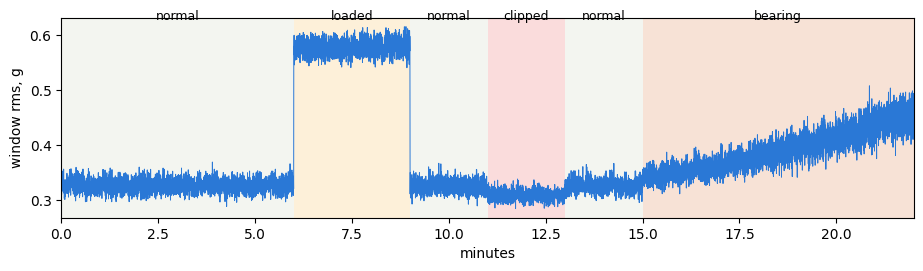

In [5]:
session = chain.make_session(seed=101)
W, t, truth = session["W"], session["t"], session["truth"]
print(f"{len(t)} windows of {W.shape[1]} samples, "
      f"{1/session['hop_s']:.3f} windows per second")

rms = np.sqrt((W ** 2).mean(1))
fig, ax = plt.subplots(figsize=(11, 2.6))
for a, b, s in chain.SCRIPT:
    ax.axvspan(a, b, color={"normal": "#f3f5f0", "loaded": "#fdf0d9",
                            "clipped": "#fadcdc", "bearing": "#f7e2d6"}[s], lw=0)
    ax.text((a + b) / 2, rms.max() * 1.02, s, ha="center", fontsize=9)
ax.plot(t / 60, rms, lw=0.7, color="#2a78d6")
ax.set_xlabel("minutes"); ax.set_ylabel("window rms, g"); ax.set_xlim(0, 22)
plt.show()

Look at that plot before reading on, and notice how little it tells you. The heavy cut
(6–9) and the spall (15 onwards) are both "the signal got bigger". The sensor fault
(11–13) is barely visible at all — a clipped accelerometer produces a signal with a
*smaller* rms, which is why Lecture 13 argued that clipping does not make a fault noisy,
it **erases** it.

Everything the rest of this notebook does is an attempt to tell those three apart.

## 3. One window, all the way through

Before running twenty thousand windows, run one, and print what each stage decided. This
is the cell to come back to when the live run does something you did not expect.

In [6]:
alarm0, clf0, Xh = bc.baseline_specs()
store = dl.SpecStore(dict(alarm0), dict(clf0), 3, 3)
dev = chain.Device(store)

for label, i in [("a quiet window", 1000), ("the heavy cut", 6000),
                 ("the clipped sensor", 11500), ("the spall", 19000)]:
    for j in range(i - 5, i):          # fill the persistence ring first
        dev.step(W[j])
    r = dev.step(W[i])
    print(f"{label:<20} t={t[i]/60:5.2f} min  gate={r['gate']:<14} "
          f"label={r['label']:<10} score={r['score']:6.2f}  "
          f"driver={r['driver']:<9} raised={int(r['raised'])}")

a quiet window       t= 1.09 min  gate=ok             label=uncertain  score=  2.83  driver=kurt      raised=0
the heavy cut        t= 6.56 min  gate=ok             label=imbalance  score= 25.90  driver=rms       raised=1
the clipped sensor   t=12.57 min  gate=clipped        label=-          score=  0.00  driver=-         raised=1
the spall            t=20.76 min  gate=ok             label=bearing    score= 15.73  driver=kurt      raised=1


Five things to notice, and each is a decision somebody made:

* the clipped window never reaches the classifier at all — `gate` short-circuits it, and
  `x` comes back `None`, so it is not added to the buffers the shadow test uses either;
* `raised` for a refused window is **the actuator's previous state**, not `False`. A
  broken sensor is not evidence that the machine is healthy;
* the driver name is reported with every window, because Lecture 11's `dom_freq`
  incident established that the *number* is not a severity and the *name* is what an
  engineer can act on;
* the quiet window comes back `uncertain`, not `normal`. Its classifier margin is under
  0.25, and Lecture 11's rule is that a model too close to its own boundary should say
  so rather than guess;
* the heavy cut raises the alarm and says `rms`. That is correct behaviour from an
  anomaly detector — the machine really is outside its baseline — and it is also a
  nuisance alarm. Telling those apart is not the detector's job; it is the driver name's.

## 4. The whole chain

`run_session` steps the device through every window, hands each result to the uplink,
delivers the scheduled updates and network events at the right moment, and lets the
cloud subscriber see whatever actually reached the broker.

It takes a few seconds. While it runs, note what it is **not** doing: there is no
retraining, no smoothing of the ground truth, and no knowledge anywhere in the device of
what the script says is happening.

In [7]:
ups = bc.make_updates(alarm0)
rec = chain.run_session(session, alarm0, clf0, ups)

for tt, kind, why in rec["events"]:
    print(f"{tt/60:6.2f} min  {kind:<18} {why}")

  3.00 min  update good        accepted: committed
  5.00 min  update over-tight  refused: shadow test: would raise on 100% of a quiet stretch
 17.50 min  update deaf        refused: shadow test: deaf: raises on only 0% of the windows that alarmed last time
 18.00 min  network down       the WiFi is pulled out
 20.00 min  network up         and put back


Two of the three updates were refused, and the reasons are worth reading carefully.

* **`accepted: committed`** — this is the one we wanted.
* **`refused: shadow test: would raise on 100% of a quiet stretch...`** — the spec was fitted on a stretch that was
  quieter than reality, so its standard deviations are too small and ordinary running
  looks anomalous. The **quiet** half of the shadow test caught it.
* **`refused: shadow test: deaf: raises on only 0% of the windows that alar...`** — the spec's standard deviations are too large, so
  nothing ever exceeds the threshold. Healthy data cannot detect this, by construction.
  The **retained-alarm** half caught it.

Neither bad spec was malformed. Both had twelve finite features, no zero standard
deviation, a threshold inside the allowed range, a correct checksum and a fresh
timestamp. `validate()` had nothing to object to. Only *running* them found them out,
which is the whole argument of Lecture 13 arriving in one line of output.

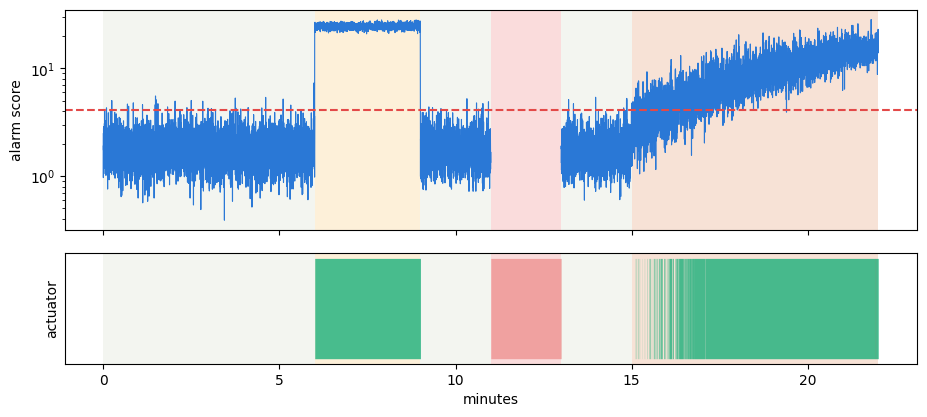

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 4.6), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1], "hspace": 0.14})
ok = rec["gate"] == "ok"
axes[0].plot(rec["t"] / 60, np.where(ok, rec["score"], np.nan), lw=0.8, color="#2a78d6")
axes[0].axhline(store.alarm["threshold"], color="#e34948", ls="--")
axes[0].set_yscale("log"); axes[0].set_ylabel("alarm score")
axes[1].fill_between(rec["t"] / 60, 0, rec["raised"].astype(float), step="mid",
                     color="#1baf7a", alpha=0.8, lw=0)
axes[1].fill_between(rec["t"] / 60, 0, (~ok).astype(float), step="mid",
                     color="#e34948", alpha=0.4, lw=0)
axes[1].set_yticks([]); axes[1].set_ylabel("actuator"); axes[1].set_xlabel("minutes")
for a, b, s in chain.SCRIPT:
    for ax in axes:
        ax.axvspan(a, b, color={"normal": "#f3f5f0", "loaded": "#fdf0d9",
                                "clipped": "#fadcdc", "bearing": "#f7e2d6"}[s],
                   lw=0, zorder=0)
plt.show()

## 5. The checkpoints

A run that "looked fine" is not evidence. This is the list you will hold the live run
to, and every line of it is a claim somebody could have got wrong.

Notice that four of the 12 are about the system **declining** to do
something: refusing two updates, holding the actuator through a sensor fault, and
publishing nothing while the link is down. In a protection system, most of the
engineering is in the refusals.

In [9]:
checks = chain.checkpoints(rec, session)
w = max(len(c["checkpoint"]) for c in checks)
for c in checks:
    print(f"[{'PASS' if c['pass'] else 'FAIL'}] {c['checkpoint']:<{w}}  {c['observed']}")
print(f"\n{sum(c['pass'] for c in checks)} of {len(checks)}")

[PASS] quiet start                                0.0%
[PASS] good update accepted                       accepted: committed
[PASS] the flooding spec refused                  refused: shadow test: would raise on 100% of a quiet
[PASS] the deaf spec refused                      refused: shadow test: deaf: raises on only 0% of the
[PASS] heavy cut raises the alarm                 raised 100%, driver rms
[PASS] sensor fault caught by the gate            100% rejected
[PASS] actuator held during the sensor fault      0 transitions
[PASS] the spall raises the alarm                 raised 100%, driver e_hi
[PASS] the cloud alerts, and only on the spall    alert at 16.0 min
[PASS] the device keeps deciding with no network  1830 windows decided
[PASS] nothing published while the link is down   3 queued
[PASS] queued reports arrive on reconnect         0 still queued at the end

12 of 12


Some numbers from the run, for the record:

| | |
|---|---|
| windows decided | 20,130 |
| messages published | 31 |
| bytes on the wire | 3,485 (0.23 MB/day at this rate) |
| the same session as raw samples | 5.3 MB |
| cloud alert | minute 16.0, 1 min after onset |
| windows decided with no network | 1,830 |
| reports queued and later delivered | 3 |

## 6. Where the shadow test stops working

This is the most important section in the notebook, and it is the one that does not
appear on any slide as a success.

The deaf spec was refused because the device had kept windows from a fault it was
**already detecting**, and the spec failed to raise on them. That is a strong test. But
it can only ever test against faults the device has already seen.

So: push the same deaf spec at different moments in the same run, and see when it gets
in.

In [10]:
import copy

times, outcomes = np.arange(12.0, 19.01, 0.5), []
for tm in times:
    saved = dict(chain.UPDATE_TIMES)
    chain.UPDATE_TIMES["deaf"] = float(tm)
    ups_i = bc.make_updates(alarm0)
    ri = chain.run_session(session, alarm0, clf0, ups_i)
    why = {k: w for _, k, w in ri["events"]}.get("update deaf", "")
    outcomes.append(why.startswith("accepted"))
    chain.UPDATE_TIMES.update(saved)

for tm, acc in zip(times, outcomes):
    print(f"  pushed at {tm:5.1f} min   {'ACCEPTED (deaf spec is now running)' if acc else 'refused'}")

  pushed at  12.0 min   ACCEPTED (deaf spec is now running)
  pushed at  12.5 min   ACCEPTED (deaf spec is now running)
  pushed at  13.0 min   ACCEPTED (deaf spec is now running)
  pushed at  13.5 min   ACCEPTED (deaf spec is now running)
  pushed at  14.0 min   ACCEPTED (deaf spec is now running)
  pushed at  14.5 min   ACCEPTED (deaf spec is now running)
  pushed at  15.0 min   ACCEPTED (deaf spec is now running)
  pushed at  15.5 min   ACCEPTED (deaf spec is now running)
  pushed at  16.0 min   ACCEPTED (deaf spec is now running)
  pushed at  16.5 min   refused
  pushed at  17.0 min   refused
  pushed at  17.5 min   refused
  pushed at  18.0 min   refused
  pushed at  18.5 min   refused
  pushed at  19.0 min   refused


The fault starts at minute 15. The device starts raising on it a little after that, and
its retained-alarm buffer only turns over to spall windows some time later. Push the
deaf spec **before** that moment and it is accepted, because the windows the device is
testing against are the heavy-cut ones — amplitude, not impulse — and a deaf spec still
raises on those.

Read the boundary off the output above. Then hold two ideas at once:

1. The shadow test is the best defence in this course. It caught a spec that every
   arithmetic check passed.
2. It cannot defend against a spec that is deaf to a fault the device has **never seen**
   — which, on a new machine, on a new fault type, or on the first unit of a fleet, is
   every fault.

That is not a bug to be fixed in `downlink.py`. It is a property of testing against your
own history, and the mitigations are organisational: stage updates on a few machines
first, keep a labelled regression set in the cloud that includes faults from *other*
machines, and make the person who approved the refit look at the detection numbers
before the fleet gets it. Exercise 6 asks you to design one of those.

## 7. What being careful cost

Every safety mechanism in this system is a trade. The course's honesty test is whether
you can state the cost of each one without looking it up.

| mechanism | what it bought | what it cost |
|---|---|---|
| 3-of-5 persistence | nuisance machines 25 % → 1.5 % | 0.022 of recall, 256 ms |
| the validity gate | 5 of 6 sensor faults caught | ~99 µs/window, and it misses a loose mount |
| validate → verify → commit | 2 of 2 bad specs refused today | a spec deaf to a new fault still gets in |
| on-change + counting heartbeat | 0.23 MB/day | no waveform to re-examine later |
| deciding at the edge | 1,830 windows decided with no link | the cloud sees less than it could |

The one that is easiest to forget is the last row of the middle column: **the gate costs
about 8 % of the device's pipeline** and it is the cheapest insurance in the system.
Students routinely delete it because it "does nothing" — it does nothing on 99.99 % of
windows, which is exactly what a working gate looks like.

In [11]:
bytes_sent = rec["broker"].tx_bytes
raw = rig.FS * 2 * chain.SESSION_MIN * 60          # int16 samples, no protocol at all
print(f"raw samples for this session : {raw/1e6:8.2f} MB")
print(f"what we actually sent        : {bytes_sent/1e3:8.2f} kB  "
      f"({raw/bytes_sent:,.0f}x less)")
print(f"messages                     : {rec['broker'].tx_msgs}")
print(f"queued while offline         : {rec['uplink'].queued}, "
      f"{len(rec['uplink'].queue)} still queued at the end")

raw samples for this session :     5.28 MB
what we actually sent        :     3.48 kB  (1,515x less)
messages                     : 31
queued while offline         : 3, 0 still queued at the end


## 8. The protocol

Ten rules. They are the answer to "what do I actually do on Monday", and every one of
them cost somebody a bad afternoon at some point.

1. **Decide on the device.** Anything whose failure can hurt somebody must not need a
   network. Reporting can need a network; acting cannot.
2. **Check the sensor before you trust the model.** A model has no way to tell a quiet
   machine from a dead cable, and it will answer confidently either way.
3. **Hold the actuator when the input is bad.** Not open, not closed — held, and said
   out loud in a message.
4. **Report the driver name, not just the score.** The number is "over threshold"; the
   name is what a technician can walk up to the machine and check.
5. **Persistence and dwell, always.** One window is a sample, not an event.
6. **Send what changed, plus a heartbeat that carries a count.** The count is six bytes
   and it recovers most of the latency the on-change policy gives away.
7. **Never apply a spec you have not run.** Validate the arithmetic, then run it against
   windows you kept: a quiet stretch *and* a stretch that alarmed.
8. **Keep the last good spec, and be able to go back.** Two slots, one pointer.
9. **A named human approves a refit.** If the retrain makes it worse, somebody has to
   own that, and "the pipeline did it" is not an owner.
10. **Write down what the system cannot do.** Every limit in section 7 of this notebook
    was discovered by testing for it. The ones you do not test for are still there.

## 9. Exercises

**1. Break a join.** Comment out the `self.hist[:] = 0` line in `Device.on_commit` and
re-run. Find a window where the alarm now behaves differently and explain, in two
sentences, exactly which stale value caused it. Then argue whether clearing the ring is
right — there is a defensible case for keeping it.

**2. The actuator's default.** Change the gate branch in `Device.step` so a refused
window returns `raised=False` instead of holding. Re-run and report which checkpoints
fail. Then state the plant condition under which your version would be the safer one.

**3. Move the fault.** Set the bearing segment to start at minute 8 instead of 15, so
the spall overlaps the heavy cut. Which checkpoints break, and is the system wrong or is
the checkpoint wrong?

**4. Saturate the sensor.** In `make_session`, change the spall growth from
`0.55 + 1.30 * frac` to `0.55 + 1.90 * frac`. Past minute 20 the impulses reach the
±2 g rail and the validity gate starts calling the sensor clipped — refusing the very
windows you most want. Report the fraction refused, and propose a change that
distinguishes "the sensor is broken" from "the machine is now too violent for this
sensor". Your answer must not simply widen the limit.

**5. A cheaper heartbeat.** The summary message is sent every 60 s. Halve the rate and re-measure both the bytes and the cloud alert time. Plot
the trade-off over four rates and mark the knee.

**6. Regression set.** Section 6 showed the shadow test cannot catch a spec that is deaf
to an unseen fault. Design a cloud-side regression set that could: say what is in it,
where the data comes from, who curates it, how big it is, and what the device would have
to be told. Half a page, and it must be something a plant could actually run.

**7. Two machines.** `run_session` drives one device. Run two in the same script with
different seeds, publishing to `rig-07` and `rig-08`, and write a cloud rule that alerts
only when **one** machine departs from the other. What does that rule get right that a
per-machine threshold does not, and what does it now get wrong?

**8. The observation sheet.** Take the checkpoint list and rewrite each line as
something a person in the lab can see or hear within ten seconds — an LED, a printed
line, a number on a dashboard. Any checkpoint you cannot turn into an observation is a
checkpoint that will not be checked.

## 10. References

* Randall, R. B. (2021). *Vibration-based Condition Monitoring*, 2nd ed. Wiley.
  Chapters 3 and 5 for the bearing signatures this course synthesises.
* Sculley, D., Holt, G., Golovin, D., et al. (2015). "Hidden technical debt in machine
  learning systems." *NeurIPS 2015*. The paper behind Lecture 13, and behind section 6
  of this notebook.
* Breck, E., Cai, S., Nielsen, E., Salib, M., Sculley, D. (2017). "The ML test score: a
  rubric for ML production readiness and technical debt reduction." *IEEE Big Data 2017*.
* ISO 20816-3:2022. *Mechanical vibration — Measurement and evaluation of machine
  vibration, Part 3: Industrial machinery.* Where real alarm limits come from when you
  are not allowed to derive your own.
* Banbury, C., Reddi, V. J., Lam, M., et al. (2021). "Benchmarking TinyML systems."
  *MLSys 2021*. For the C/TFLite world this course deliberately stayed out of.
* MicroPython documentation, `machine.ADC`, `micropython.native`, and the memory
  guidance in "Maximising MicroPython speed": https://docs.micropython.org
* NETPIE 2020 documentation: https://netpie.io/